In [167]:
import pandas as pd
import numpy as np
from preparing_data import *
from catboost import CatBoostClassifier, Pool
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [168]:
df = pd.read_parquet("history_data.parquet")

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47470 entries, 0 to 47469
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  47470 non-null  datetime64[ns]
 1   open       47470 non-null  float64       
 2   high       47470 non-null  float64       
 3   low        47470 non-null  float64       
 4   close      47470 non-null  float64       
 5   volume     47470 non-null  float64       
 6   symbol     47470 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 2.5+ MB


In [170]:
def calculate_max_drawdown(series):
    rolling_max = series.cummax()
    drawdown = (series - rolling_max) / rolling_max
    return drawdown.cummin()

df = df.sort_values(["symbol", "timestamp"])
df["ret_1"] = df.groupby("symbol")["close"].pct_change()
df = df.fillna(0)
closed = df.groupby("symbol")["close"]
windows = (1,7,20,50)
for window in windows:
    
    df[f"ret_{window}"] = closed.pct_change(window)

    df[f"vol_{window}"] = (
        df.groupby("symbol")["ret_1"]
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"volume_z_{window}"] = (
        df.groupby("symbol")["volume"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )

    df[f"price_z_{window}"] = (
        df.groupby("symbol")["close"]
        .transform(lambda x: (x - x.rolling(window).mean()) / (x.rolling(window).std() + 1e-12))
    )
    df[f"high_{window}"] = df.groupby("symbol")["high"].transform(
    lambda x: x.rolling(window).max().shift(1)
    )

df["net_return"] = closed.transform(lambda x: (x / x.iloc[0]) - 1)
df["max_drawdown"] = closed.transform(calculate_max_drawdown)

future_return = df.groupby("symbol")["close"].transform(
lambda x: x.pct_change(3).shift(-3)
)

df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

df["signal_long"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 1)
).astype(int)

# df["target_good_trade"] = (future_return > 0.02).astype(int)


df["candle_range"] = (df["high"] - df["low"]) / df["close"]
df["body_size"] = abs(df["close"] - df["open"]) / df["open"]

btc = df[df["symbol"] == "BTCUSDT"][["timestamp", "ret_1", "ret_7", "ret_20", "ret_50" ,"vol_20", "vol_50"]].copy()

btc = btc.rename(columns={
    "ret_1": "btc_ret_1",
    "ret_7": "btc_ret_7",
    "ret_20": "btc_ret_20",
    "ret_50": "btc_ret_50",
    "vol_20": "btc_vol_20",
    "vol_50": "btc_vol_50",
})

df = df.merge(btc, on="timestamp", how="left")

df["rel_ret_7"] = df["ret_7"] - df["btc_ret_7"]
df["rel_ret_20"] = df["ret_20"] - df["btc_ret_20"]
df["rel_ret_50"] = df["ret_50"] - df["btc_ret_50"]

delta = df.groupby("symbol")["close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df["symbol"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / (avg_loss + 1e-12)

df["rsi_14"] = 100 - (100 / (1 + rs))

df["signal_breakout"] = (
    (df["close"] > df["high_20"]) &
    (df["volume_z_20"] > 0.5)
).astype(int)

df["signal_mean_reversion"] = (
    (df["rsi_14"] < 35) &
    (df["price_z_20"] < -1.0)
).astype(int)
display(df)

,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,btc_ret_20,btc_ret_50,btc_vol_20,btc_vol_50,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,signal_breakout,signal_mean_reversion
0,2026-05-25 05:00:00,85.3300,86.0200,85.3300,85.5300,2489.863,AAVEUSDT,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2026-05-25 06:00:00,85.5400,85.6700,85.2500,85.4500,2601.873,AAVEUSDT,-0.000935,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2026-05-25 07:00:00,85.4600,86.2000,85.4200,86.1300,1970.830,AAVEUSDT,0.007958,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2026-05-25 08:00:00,86.1300,86.5600,86.0800,86.5000,3710.690,AAVEUSDT,0.004296,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2026-05-25 09:00:00,86.4800,86.7000,86.2000,86.5600,3398.104,AAVEUSDT,0.000694,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47465,2026-07-05 16:00:00,1.1357,1.1370,1.1308,1.1355,1217176.800,XRPUSDT,-0.000176,NaN,NaN,...,-0.007718,0.012382,0.002045,0.002517,-0.002791,-0.031134,0.010591,27.044025,0,0
47466,2026-07-05 17:00:00,1.1356,1.1380,1.1336,1.1372,803020.600,XRPUSDT,0.001497,NaN,NaN,...,-0.005707,0.013362,0.002026,0.002514,0.000494,-0.026463,0.013269,35.180723,0,0
47467,2026-07-05 18:00:00,1.1372,1.1414,1.1347,1.1370,2079528.900,XRPUSDT,-0.000176,NaN,NaN,...,-0.008764,0.010046,0.001965,0.002507,0.001201,-0.018110,0.013080,38.829787,0,0
47468,2026-07-05 19:00:00,1.1371,1.1390,1.1340,1.1349,1659998.000,XRPUSDT,-0.001847,NaN,NaN,...,-0.009430,0.007560,0.001980,0.002519,0.006051,-0.014564,0.012850,46.056782,0,0


In [171]:
horizon = 3
fee = 0.001

df["entry_price"] = df.groupby("symbol")["open"].shift(-1)
df["exit_price"] = df.groupby("symbol")["close"].shift(-horizon)

future_lows = []

for i in range(1, horizon + 1):
    future_lows.append(df.groupby("symbol")["low"].shift(-i))

df["future_min_low"] = pd.concat(future_lows, axis=1).min(axis=1)

df["net_return"] = df["exit_price"] / df["entry_price"] - 1 - 2 * fee
df["max_drawdown"] = df["future_min_low"] / df["entry_price"] - 1

df["target_good_trade"] = (
    (df["net_return"] > 0.002) &
    (df["max_drawdown"] > -0.015)
).astype(int)

In [172]:
df = df.fillna(0)
df


,timestamp,open,high,low,close,volume,symbol,ret_1,vol_1,volume_z_1,...,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,signal_breakout,signal_mean_reversion,entry_price,exit_price,future_min_low,target_good_trade
0,2026-05-25 05:00:00,85.3300,86.0200,85.3300,85.5300,2489.863,AAVEUSDT,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,85.5400,86.5000,85.2500,1
1,2026-05-25 06:00:00,85.5400,85.6700,85.2500,85.4500,2601.873,AAVEUSDT,-0.000935,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,85.4600,86.5600,85.4200,1
2,2026-05-25 07:00:00,85.4600,86.2000,85.4200,86.1300,1970.830,AAVEUSDT,0.007958,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,86.1300,86.6200,86.0800,1
3,2026-05-25 08:00:00,86.1300,86.5600,86.0800,86.5000,3710.690,AAVEUSDT,0.004296,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,86.4800,86.7100,86.2000,0
4,2026-05-25 09:00:00,86.4800,86.7000,86.2000,86.5600,3398.104,AAVEUSDT,0.000694,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0,0,86.5600,86.7900,86.2000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47465,2026-07-05 16:00:00,1.1357,1.1370,1.1308,1.1355,1217176.800,XRPUSDT,-0.000176,0.0,0.0,...,-0.002791,-0.031134,0.010591,27.044025,0,0,1.1356,1.1349,1.1336,0
47466,2026-07-05 17:00:00,1.1356,1.1380,1.1336,1.1372,803020.600,XRPUSDT,0.001497,0.0,0.0,...,0.000494,-0.026463,0.013269,35.180723,0,0,1.1372,1.1348,1.1319,0
47467,2026-07-05 18:00:00,1.1372,1.1414,1.1347,1.1370,2079528.900,XRPUSDT,-0.000176,0.0,0.0,...,0.001201,-0.018110,0.013080,38.829787,0,0,1.1371,0.0000,1.1319,0
47468,2026-07-05 19:00:00,1.1371,1.1390,1.1340,1.1349,1659998.000,XRPUSDT,-0.001847,0.0,0.0,...,0.006051,-0.014564,0.012850,46.056782,0,0,1.1349,0.0000,1.1319,0


In [173]:
feature_cols = [
    "symbol",
    "ret_1",
    "ret_7",
    "ret_20",
    "ret_50",
    "vol_7",
    "vol_20",
    "vol_50",
    "volume_z_20",
    "volume_z_50",
    "price_z_20",
    "price_z_50",
    "candle_range",
    "body_size",
    "btc_ret_1",
    "btc_ret_7",
    "btc_ret_50",
    "btc_vol_20",
    "btc_vol_50",
    "rel_ret_7",
    "rel_ret_20",
    "rel_ret_50",
    "rsi_14",
    "strategy_name",
    
]

breakout_trades = df[df["signal_breakout"] == 1].copy()
breakout_trades["strategy_name"] = "breakout"

mean_reversion_trades = df[df["signal_mean_reversion"] == 1].copy()
mean_reversion_trades["strategy_name"] = "mean_reversion"

ml_dataset = pd.concat(
    [breakout_trades, mean_reversion_trades],
    ignore_index=True
)

ml_dataset = ml_dataset[
    ["timestamp", "entry_price", "exit_price", "net_return", "max_drawdown", "target_good_trade"]
    + feature_cols
]

ml = ml_dataset.dropna().sort_values("timestamp")


In [174]:
display(
    ml,
    ml.info()
)

<class 'pandas.core.frame.DataFrame'>
Index: 8348 entries, 2740 to 6058
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          8348 non-null   datetime64[ns]
 1   entry_price        8348 non-null   float64       
 2   exit_price         8348 non-null   float64       
 3   net_return         8348 non-null   float64       
 4   max_drawdown       8348 non-null   float64       
 5   target_good_trade  8348 non-null   int64         
 6   symbol             8348 non-null   object        
 7   ret_1              8348 non-null   float64       
 8   ret_7              8348 non-null   float64       
 9   ret_20             8348 non-null   float64       
 10  ret_50             8348 non-null   float64       
 11  vol_7              8348 non-null   float64       
 12  vol_20             8348 non-null   float64       
 13  vol_50             8348 non-null   float64       
 14  volume_z_2

,timestamp,entry_price,exit_price,net_return,max_drawdown,target_good_trade,symbol,ret_1,ret_7,ret_20,...,btc_ret_1,btc_ret_7,btc_ret_50,btc_vol_20,btc_vol_50,rel_ret_7,rel_ret_20,rel_ret_50,rsi_14,strategy_name
2740,2020-07-25 08:00:00,1.01590,1.0089,-0.008890,-0.009745,0,DAIUSDT,-0.001178,-0.015191,-0.016333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.917874,mean_reversion
2741,2020-07-25 09:00:00,1.00880,1.0064,-0.004379,-0.003469,0,DAIUSDT,-0.007664,-0.025943,-0.024155,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.176221,mean_reversion
2742,2020-07-25 10:00:00,1.01130,1.0073,-0.005955,-0.009493,0,DAIUSDT,0.001188,-0.024973,-0.022050,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.394850,mean_reversion
2743,2020-07-25 11:00:00,1.00590,1.0052,-0.002696,-0.004175,0,DAIUSDT,-0.002275,-0.024935,-0.021435,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.338330,mean_reversion
2744,2020-07-25 12:00:00,1.00550,1.0018,-0.005680,-0.005072,0,DAIUSDT,-0.002478,-0.023387,-0.027445,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.102041,mean_reversion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,2026-07-05 18:00:00,45.44000,0.0000,0.000000,-0.009463,0,LTCUSDT,0.005976,0.022037,0.006199,...,-0.001150,-0.002781,0.010046,0.001965,0.002507,0.024819,0.014963,0.029762,74.766355,breakout
4546,2026-07-05 18:00:00,0.26790,0.0000,0.000000,-0.001866,0,LDOUSDT,-0.001863,-0.009978,-0.016881,...,-0.001150,-0.002781,0.010046,0.001965,0.002507,-0.007196,-0.008117,-0.012652,33.714286,mean_reversion
7702,2026-07-05 18:00:00,3.14600,0.0000,0.000000,-0.001271,0,UNIUSDT,0.000000,-0.016880,-0.029021,...,-0.001150,-0.002781,0.010046,0.001965,0.002507,-0.014099,-0.020257,-0.051496,33.834586,mean_reversion
3815,2026-07-05 19:00:00,0.02807,0.0000,0.000000,-0.000356,0,FLOWUSDT,-0.001425,0.000000,-0.025721,...,-0.001634,0.000244,0.007560,0.001980,0.002519,-0.000244,-0.016291,-0.013236,16.666666,mean_reversion


None

In [175]:
display(
    ml.shape,
    ml["target_good_trade"].value_counts(normalize=True),
    ml["strategy_name"].value_counts()
)

(8348, 30)

target_good_trade
0    0.659679
1    0.340321
Name: proportion, dtype: float64

strategy_name
mean_reversion    7231
breakout          1117
Name: count, dtype: int64

In [176]:
split = 0.8
ml = ml.sort_values("timestamp")

split_date = ml_dataset["timestamp"].quantile(split)

train = ml_dataset[ml_dataset["timestamp"] <= split_date].copy()
test = ml_dataset[ml_dataset["timestamp"] > split_date].copy()

In [177]:
X_train = train[feature_cols]
y_train = train["target_good_trade"]

X_test = test[feature_cols]
y_test = test["target_good_trade"]

X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test = X_test.loc[:, ~X_test.columns.duplicated()].copy()

In [178]:
cat_features = ["symbol", "strategy_name"]
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)
predict_pool = Pool(data=X_test, cat_features=cat_features)

In [ ]:
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.03,
    depth=5,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=100,
    random_seed=42
)

model.fit(
    X=train_pool,
    eval_set=test_pool,
    early_stopping_rounds=50,
    
)

0:	test: 0.4990068	best: 0.4990068 (0)	total: 32.5ms	remaining: 9.73s
10:	test: 0.4826640	best: 0.5120579 (1)	total: 326ms	remaining: 8.56s
20:	test: 0.5080305	best: 0.5120579 (1)	total: 614ms	remaining: 8.16s
30:	test: 0.5233926	best: 0.5363633 (27)	total: 875ms	remaining: 7.59s
40:	test: 0.5094927	best: 0.5363633 (27)	total: 1.17s	remaining: 7.41s
50:	test: 0.5221104	best: 0.5363633 (27)	total: 1.45s	remaining: 7.08s
60:	test: 0.5292211	best: 0.5363633 (27)	total: 1.78s	remaining: 6.96s
70:	test: 0.5365433	best: 0.5377829 (66)	total: 2.04s	remaining: 6.58s
80:	test: 0.5441056	best: 0.5441056 (80)	total: 2.32s	remaining: 6.27s
90:	test: 0.5512146	best: 0.5512146 (90)	total: 2.63s	remaining: 6.05s
100:	test: 0.5515731	best: 0.5526879 (93)	total: 2.88s	remaining: 5.67s
110:	test: 0.5515573	best: 0.5526879 (93)	total: 3.13s	remaining: 5.33s
120:	test: 0.5532090	best: 0.5535296 (118)	total: 3.41s	remaining: 5.05s
130:	test: 0.5498550	best: 0.5541581 (123)	total: 3.71s	remaining: 4.79s
140

CatBoostClassifier(depth=5, eval_metric='AUC', iterations=300, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=10)

,timestamp,symbol,strategy_name,prob_good_trade,risk_score,target_good_trade,trade_allowed
22,2026-06-25 01:00:00,AAVEUSDT,breakout,0.093872,0.906128,1,0
23,2026-06-26 18:00:00,AAVEUSDT,breakout,0.063419,0.936581,1,0
24,2026-06-26 19:00:00,AAVEUSDT,breakout,0.078746,0.921254,0,0
25,2026-06-26 20:00:00,AAVEUSDT,breakout,0.107955,0.892045,0,0
26,2026-06-29 06:00:00,AAVEUSDT,breakout,0.294806,0.705194,0,0
...,...,...,...,...,...,...,...
8343,2026-07-05 10:00:00,XRPUSDT,mean_reversion,0.221713,0.778287,0,0
8344,2026-07-05 11:00:00,XRPUSDT,mean_reversion,0.251579,0.748421,0,0
8345,2026-07-05 12:00:00,XRPUSDT,mean_reversion,0.317181,0.682819,1,0
8346,2026-07-05 13:00:00,XRPUSDT,mean_reversion,0.248699,0.751301,1,0


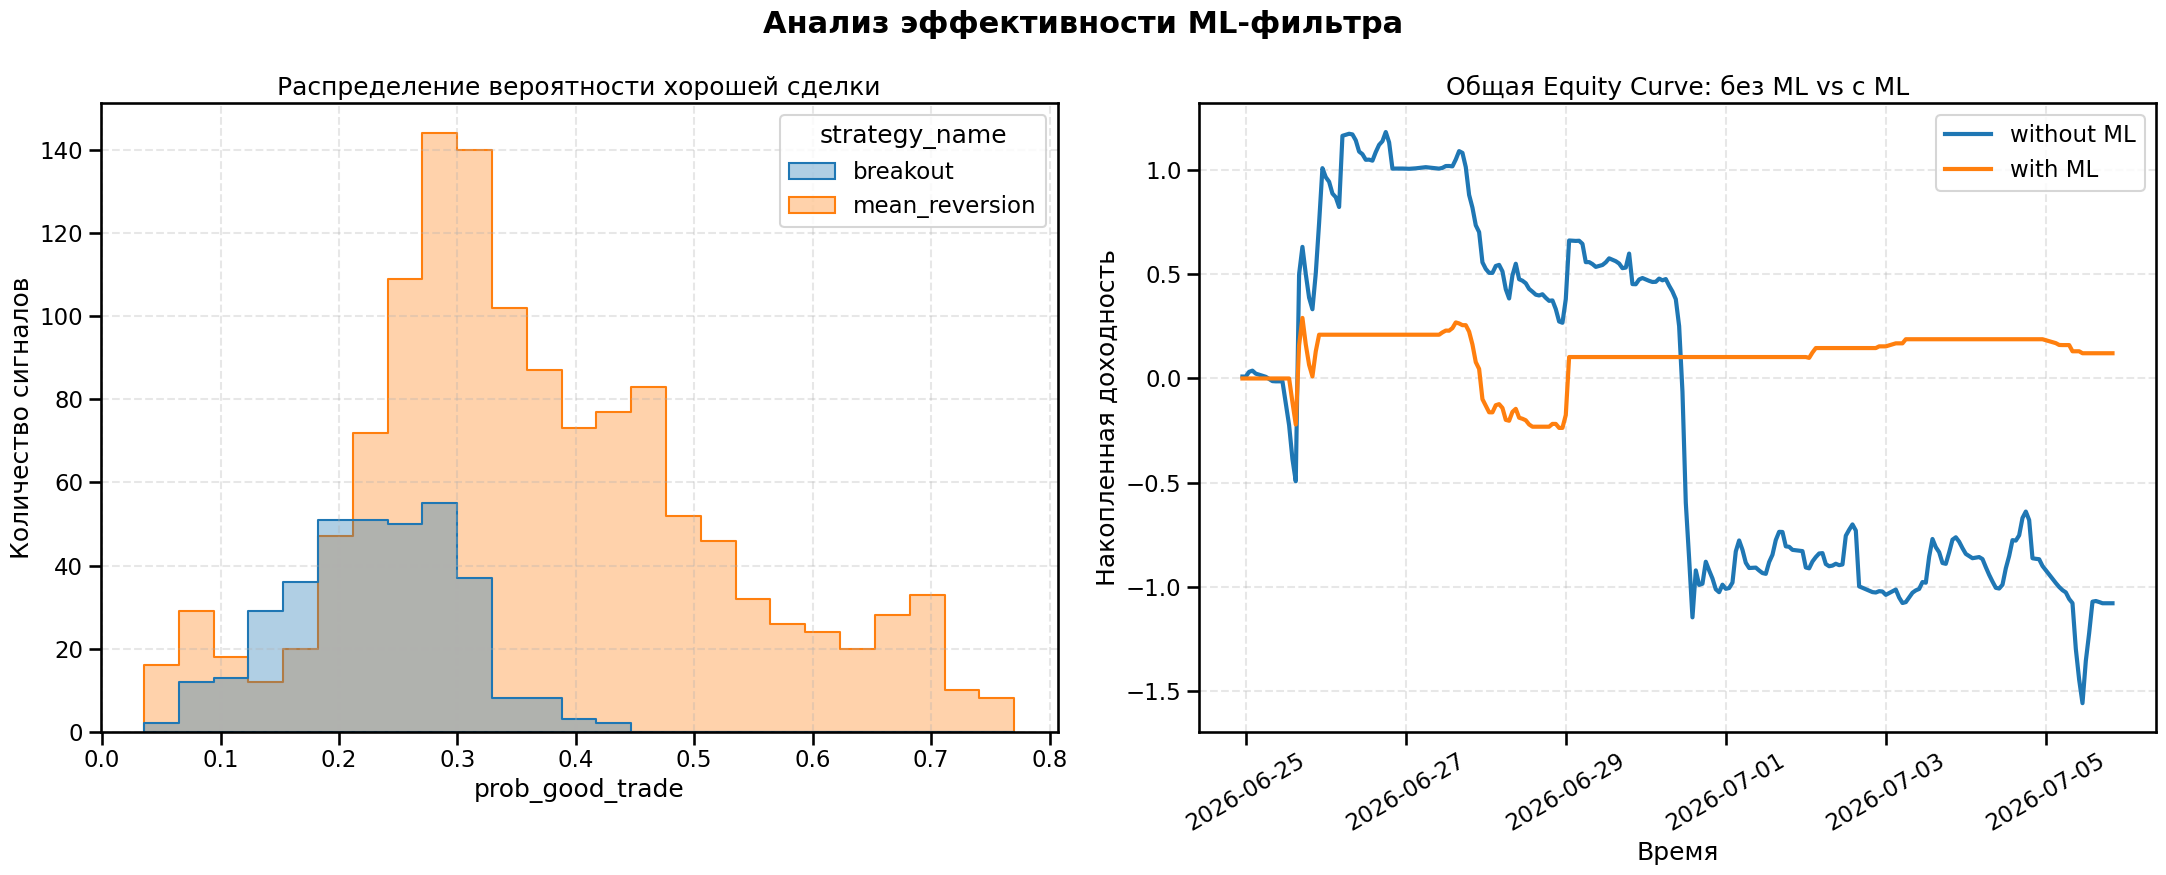

In [186]:
test["prob_good_trade"] = model.predict_proba(predict_pool)[:, 1]
test["risk_score"] = 1 - test["prob_good_trade"]
test["trade_allowed"] = (test["prob_good_trade"] > 0.45).astype(int)
test_res = test[["timestamp", "symbol", "strategy_name", "prob_good_trade", "risk_score", "target_good_trade", "trade_allowed"]]
display(test_res)

plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
sns.set_context("talk")

test_res = test.copy()
test_res["timestamp"] = pd.to_datetime(test_res["timestamp"])
test_res = test_res.sort_values("timestamp")

# доходность без фильтра
test_res["return_without_ml"] = test_res["net_return"]

# доходность с ML-фильтром
test_res["return_with_ml"] = test_res["net_return"] * test_res["trade_allowed"]

# общий equity по всем стратегиям
equity_total = (
    test_res
    .groupby("timestamp", as_index=False)[["return_without_ml", "return_with_ml"]]
    .sum()
    .sort_values("timestamp")
)

equity_total["equity_without_ml"] = equity_total["return_without_ml"].cumsum()
equity_total["equity_with_ml"] = equity_total["return_with_ml"].cumsum()

# equity отдельно по стратегиям
equity_by_strategy = (
    test_res
    .groupby(["strategy_name", "timestamp"], as_index=False)[
        ["return_without_ml", "return_with_ml"]
    ]
    .sum()
    .sort_values(["strategy_name", "timestamp"])
)

equity_by_strategy["equity_without_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_without_ml"]
    .cumsum()
)

equity_by_strategy["equity_with_ml"] = (
    equity_by_strategy
    .groupby("strategy_name")["return_with_ml"]
    .cumsum()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

fig.suptitle(
    "Анализ эффективности ML-фильтра",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

# распределение вероятностей
sns.histplot(
    data=test_res,
    x="prob_good_trade",
    hue="strategy_name",
    bins=25,
    element="step",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)

axes[0].set_title("Распределение вероятности хорошей сделки")
axes[0].set_xlabel("prob_good_trade")
axes[0].set_ylabel("Количество сигналов")
axes[0].grid(True, alpha=0.3, linestyle="--")

# общий equity без ML и с ML
axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_without_ml"],
    label="without ML",
    linewidth=3,
)

axes[1].plot(
    equity_total["timestamp"],
    equity_total["equity_with_ml"],
    label="with ML",
    linewidth=3,
)

axes[1].set_title("Общая Equity Curve: без ML vs с ML")
axes[1].set_xlabel("Время")
axes[1].set_ylabel("Накопленная доходность")
axes[1].legend()
axes[1].grid(True, alpha=0.3, linestyle="--")

axes[1].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

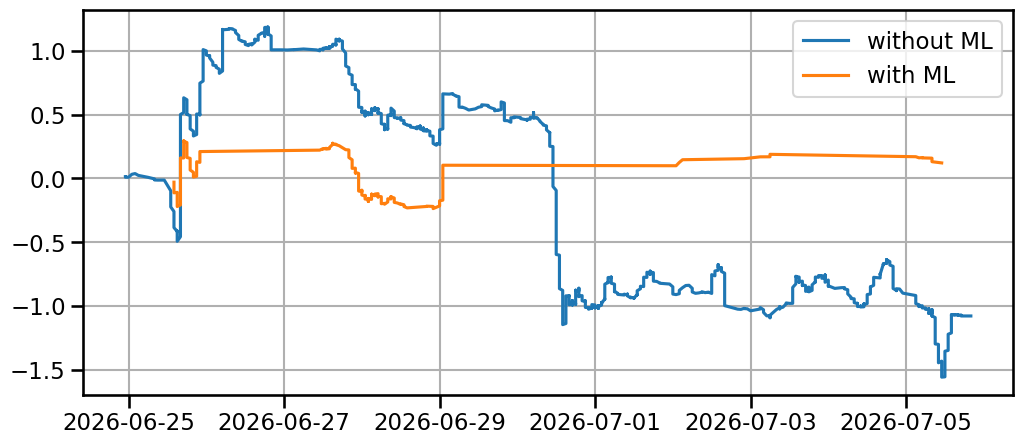

In [187]:
plot_all = test.sort_values("timestamp").copy()
plot_all["equity_without_ml"] = plot_all["net_return"].cumsum()

plot_ml = test[test["trade_allowed"] == 1].sort_values("timestamp").copy()
plot_ml["equity_with_ml"] = plot_ml["net_return"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(plot_all["timestamp"], plot_all["equity_without_ml"], label="without ML")
plt.plot(plot_ml["timestamp"], plot_ml["equity_with_ml"], label="with ML")
plt.legend()
plt.grid()
plt.show()

In [188]:
without_ml = test.copy()
with_ml = test[test["trade_allowed"] == 1].copy()

print("без ML:")
print("trades:", len(without_ml))
print("mean_return:", without_ml["net_return"].mean())
print("winrate:", (without_ml["net_return"] > 0).mean())
print("total_return:", without_ml["net_return"].sum())

print()

print("с ML:")
print("trades:", len(with_ml))
print("mean_return:", with_ml["net_return"].mean())
print("winrate:", (with_ml["net_return"] > 0).mean())
print("total_return:", with_ml["net_return"].sum())

без ML:
trades: 1665
mean_return: -0.0006478481201894491
winrate: 0.44924924924924925
total_return: -1.0786671201154328

с ML:
trades: 353
mean_return: 0.00034296865982973965
winrate: 0.46742209631728043
total_return: 0.1210679369198981
